In [ ]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [ ]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

NEW_FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Smoothed.hdf5"

--- Numerical Sanity Checks (Sample 3) ---
Contains NaNs: False
Max absolute value on u boundaries: 8.075358e-01 (Should be ~0.0)


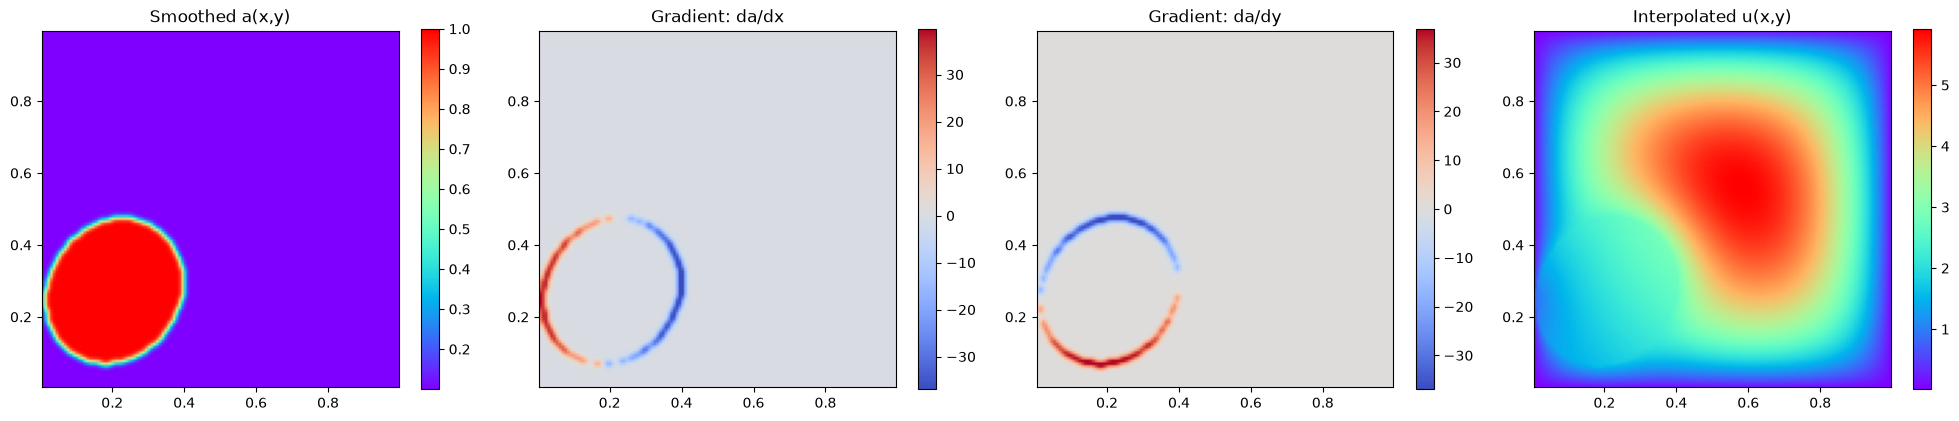

In [ ]:
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train_Smoothed.hdf5"

sample_idx = 3

with h5py.File(FILE_PATH, 'r') as f:
    # Get grid dimensions
    fine_x = f['x-coordinate'][:]
    fine_y = f['y-coordinate'][:]
    fine_nx, fine_ny = len(fine_x), len(fine_y)
    
    # Extract the sample and reshape back to 2D
    a_2d = f['a_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ax_2d = f['a_x_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ay_2d = f['a_y_flat'][sample_idx].reshape(fine_nx, fine_ny)
    u_2d = f['u_flat'][sample_idx].reshape(fine_nx, fine_ny)

print(f"--- Numerical Sanity Checks (Sample {sample_idx}) ---")
print(f"Contains NaNs: {np.isnan(a_2d).any() or np.isnan(u_2d).any()}")

# Extract the boundary pixels of u
u_boundaries = np.concatenate([
    u_2d[0, :], u_2d[-1, :],  # Left and Right edges
    u_2d[:, 0], u_2d[:, -1]   # Bottom and Top edges
])
max_boundary_val = np.max(np.abs(u_boundaries))
print(f"Max absolute value on u boundaries: {max_boundary_val:.6e} (Should be ~0.0)")

# Plot
# We transpose (.T) to match Cartesian plotting (x on horizontal, y on vertical)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ext = [fine_x.min(), fine_x.max(), fine_y.min(), fine_y.max()]

im0 = axes[0].imshow(a_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[0].set_title("Smoothed a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ax_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[1].set_title("Gradient: da/dx")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ay_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[2].set_title("Gradient: da/dy")
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(u_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[3].set_title("Interpolated u(x,y)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

In [ ]:
print(f"Loading pre-processed dataset: {NEW_FILE_PATH.name}")

with h5py.File(NEW_FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    # Load the pre-calculated, pre-flattened arrays into memory
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

# Coordinate generation
x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Because the HDF5 grid is cell-centered, all of these are strictly valid interior points
x_valid = x
y_valid = y
total_valid_points = x_valid.shape[0]

# Generate True Mathematical Boundaries
# The domain is defined mathematically as the unit square (0,1)^2
# Dynamically scale the boundary density to match the interior grid
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

# Bottom (y=0.0) and Top (y=1.0)
bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)

# Left (x=0.0) and Right (x=1.0)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

# Combine all true boundary coordinates
all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

# Enforce exactly u=0.0 on these true boundaries
bc_val_array = jnp.zeros_like(x_bc)

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


In [ ]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

n_train = 32
n_val = 5
n_test = 5
N_subset = n_train + n_val + n_test

# Slice sequentially to completely isolate the sets
train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], 
    all_a_x_flat[:n_train], 
    all_a_y_flat[:n_train], 
    all_u_flat[:n_train]
)

val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], 
    all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], 
    all_u_flat[n_train : n_train + n_val]
)

test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], 
    all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], 
    all_u_flat[n_train + n_val : N_subset]
)

batch_size_samples = 32
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

DataLoaders ready! (Train: 32, Val: 5, Test: 5)


In [ ]:
epochs = 1000
M = 512
chunk_size = 256 
hidden_layers = [512,512,512,512] 

total_features = hidden_layers[-1]

sigma = 1
tik_reg_fixed = 1e-5
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e2
data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.glorot_normal())(h)
            h = nn.tanh(h) 
        return h 
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

print(f"Calculated Total Features for V1: {total_features}")

Calculated Total Features for V1: 512


In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_x_chunk = jnp.squeeze(f_x_chunk, axis=-1)
    f_y_chunk = jnp.squeeze(f_y_chunk, axis=-1)
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_x_chunk, f_y_chunk, f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_x = jnp.dot(f_x, w_current)
    u_y = jnp.dot(f_y, w_current)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_x, u_y, u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [ ]:
total_steps = epochs * len(train_dataloader)
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=total_steps, alpha=0.01)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

def multiply_coefficients(f_x, f_y, f_xx, f_yy, a_pde, a_x_pde, a_y_pde):
    return -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))

batched_multiply = jax.vmap(multiply_coefficients, in_axes=(None, None, None, None, 0, 0, 0))

def get_A_and_b_optimized(params, x_pde, y_pde, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    # Compute Boundary Features
    A_bc_full = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(matrix_bc_weight)
        A_bc_full.append(A_bc_chunk)
    A_bc_matrix = jnp.hstack(A_bc_full)
    
    # Iterate through chunks to assemble the full PDE matrix
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        # Runs once per spatial chunk, regardless of batch size
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # Broadcasts the scalar/array multiplication across the batch
        A_pde_batch = batched_multiply(f_x, f_y, f_xx, f_yy, a_batch, a_x_batch, a_y_batch)
        
        # Slice the pre-computed boundary matrix to match the current chunk's width
        A_bc_chunk_sliced = A_bc_matrix[:, start_idx:end_idx]
        
        # Stack PDE and BC for every sample in the batch
        A_bc_batched = jnp.repeat(A_bc_chunk_sliced[None, ...], a_batch.shape[0], axis=0)
        A_chunk_batched = jnp.concatenate([A_pde_batch, A_bc_batched], axis=1)
        
        A_chunks.append(A_chunk_batched)
        
    A_full_batch = jnp.concatenate(A_chunks, axis=-1)
    
    # Assemble target vector b
    b_pde = jnp.ones_like(a_batch) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_bc_batched = jnp.repeat(b_bc[None, ...], a_batch.shape[0], axis=0)
    b_full_batch = jnp.concatenate([b_pde, b_bc_batched], axis=1)
    
    return A_full_batch, b_full_batch

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_batch, b_batch = get_A_and_b_optimized(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
        Atb = A.T @ b
        return jax.scipy.linalg.solve(AtA, Atb)
    
    return jax.vmap(solve_single)(A_batch, b_batch)

def compute_loss_single(params, w_current, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
    u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

batched_compute_loss = jax.vmap(compute_loss_single, in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, 0))

def full_forward_and_loss(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    w_batch = update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    scaled_tup, unscaled_tup = batched_compute_loss(params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch)
    
    total_scaled = jnp.mean(scaled_tup[0]) + jnp.mean(scaled_tup[1]) + jnp.mean(scaled_tup[2])
    aux_unscaled = (jnp.mean(unscaled_tup[0]), jnp.mean(unscaled_tup[1]), jnp.mean(unscaled_tup[2]))
    
    return total_scaled, aux_unscaled

loss_grad_fn = jax.jit(value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), static_argnames=['total_features', 'chunk_size'])

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    (loss_scaled, unscaled_tup), grads = loss_grad_fn(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss_scaled, unscaled_tup

def evaluate_dataset_full(dataloader, params, x_full, y_full, x_bc_full, y_bc_full, bc_val_full):
    total_loss, total_pde, total_bc, total_data = 0.0, 0.0, 0.0, 0.0
    total_samples = 0
    
    rng = jax.random.PRNGKey(99)
    val_spatial_idx = jax.random.choice(rng, jnp.arange(x_full.shape[0]), shape=(5000,), replace=False)
    x_chunk, y_chunk = x_full[val_spatial_idx], y_full[val_spatial_idx]
    val_bc_idx = jax.random.choice(rng, jnp.arange(x_bc_full.shape[0]), shape=(512,), replace=False)
    x_bc_chunk, y_bc_chunk = x_bc_full[val_bc_idx], y_bc_full[val_bc_idx]
    bc_val_chunk = bc_val_full[val_bc_idx]
    
    for a_batch, a_x_batch, a_y_batch, u_batch in dataloader:
        batch_size = a_batch.shape[0]
        
        l_scaled, (l_pde, l_bc, l_data) = full_forward_and_loss(
            params, x_chunk, y_chunk, 
            a_batch[:, val_spatial_idx, :], 
            a_x_batch[:, val_spatial_idx, :], 
            a_y_batch[:, val_spatial_idx, :], 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, 
            u_batch[:, val_spatial_idx, :], 
            total_features, chunk_size
        )
        
        total_loss += l_scaled.item() * batch_size
        total_pde += l_pde.item() * batch_size
        total_bc += l_bc.item() * batch_size
        total_data += l_data.item() * batch_size
        total_samples += batch_size
        
    return total_loss / total_samples, total_pde / total_samples, total_bc / total_samples, total_data / total_samples

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] 
spatial_batch_size = 5000 
total_bc_points = x_bc.shape[0]
bc_batch_size = 512

rng, pde_key, bc_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_key, total_points)
bc_indices = jax.random.permutation(bc_key, total_bc_points)

ptr, bc_ptr = 0, 0 

history_train = {'total': [], 'pde': [], 'bc': [], 'data': []}
history_val = {'total': [], 'pde': [], 'bc': [], 'data': []}

for epoch in tqdm(range(epochs), desc="Training Epochs"):
    epoch_loss_scaled, ep_pde, ep_bc, ep_data, num_batches = 0.0, 0.0, 0.0, 0.0, 0
    
    for a_batch, a_x_batch, a_y_batch, u_batch in train_dataloader:
        
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        x_chunk, y_chunk = x[batch_idx], y[batch_idx]
        
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        x_bc_chunk, y_bc_chunk = x_bc[bc_batch_idx], y_bc[bc_batch_idx]
        bc_val_chunk = bc_val_array[bc_batch_idx]
        
        params, opt_state, l_scaled, (l_pde, l_bc, l_data) = update_network(
            params, opt_state, x_chunk, y_chunk, 
            a_batch[:, batch_idx, :], a_x_batch[:, batch_idx, :], a_y_batch[:, batch_idx, :], 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, u_batch[:, batch_idx, :], total_features, chunk_size
        )
        
        epoch_loss_scaled += l_scaled
        ep_pde += l_pde
        ep_bc += l_bc
        ep_data += l_data
        num_batches += 1

    history_train['total'].append(float(epoch_loss_scaled / num_batches))
    history_train['pde'].append(float(ep_pde / num_batches))
    history_train['bc'].append(float(ep_bc / num_batches))
    history_train['data'].append(float(ep_data / num_batches))
    
    v_tot, v_pde, v_bc, v_dat = evaluate_dataset_full(val_dataloader, params, x, y, x_bc, y_bc, bc_val_array)
    history_val['total'].append(float(v_tot))
    history_val['pde'].append(float(v_pde))
    history_val['bc'].append(float(v_bc))
    history_val['data'].append(float(v_dat))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Total: {history_train['total'][-1]:.3e} | Val Total: {history_val['total'][-1]:.3e} | Val Data MSE: {history_val['data'][-1]:.3e}")

Training Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 001 | Train Total: 4.697e+01 | Val Total: 3.815e+01 | Val Data MSE: 8.723e-01
Epoch 011 | Train Total: 3.142e+01 | Val Total: 3.235e+01 | Val Data MSE: 9.214e-01
Epoch 021 | Train Total: 2.738e+01 | Val Total: 3.089e+01 | Val Data MSE: 9.500e-01
Epoch 031 | Train Total: 2.545e+01 | Val Total: 3.023e+01 | Val Data MSE: 1.020e+00
Epoch 041 | Train Total: 2.388e+01 | Val Total: 2.937e+01 | Val Data MSE: 9.979e-01
Epoch 051 | Train Total: 2.332e+01 | Val Total: 2.880e+01 | Val Data MSE: 9.977e-01
Epoch 061 | Train Total: 2.193e+01 | Val Total: 2.902e+01 | Val Data MSE: 1.000e+00
Epoch 071 | Train Total: 2.081e+01 | Val Total: 2.857e+01 | Val Data MSE: 9.797e-01
Epoch 081 | Train Total: 2.040e+01 | Val Total: 2.898e+01 | Val Data MSE: 9.859e-01
Epoch 091 | Train Total: 1.920e+01 | Val Total: 2.888e+01 | Val Data MSE: 1.001e+00
Epoch 101 | Train Total: 1.839e+01 | Val Total: 2.903e+01 | Val Data MSE: 1.036e+00
Epoch 111 | Train Total: 1.759e+01 | Val Total: 2.889e+01 | Val Data MSE: 1.

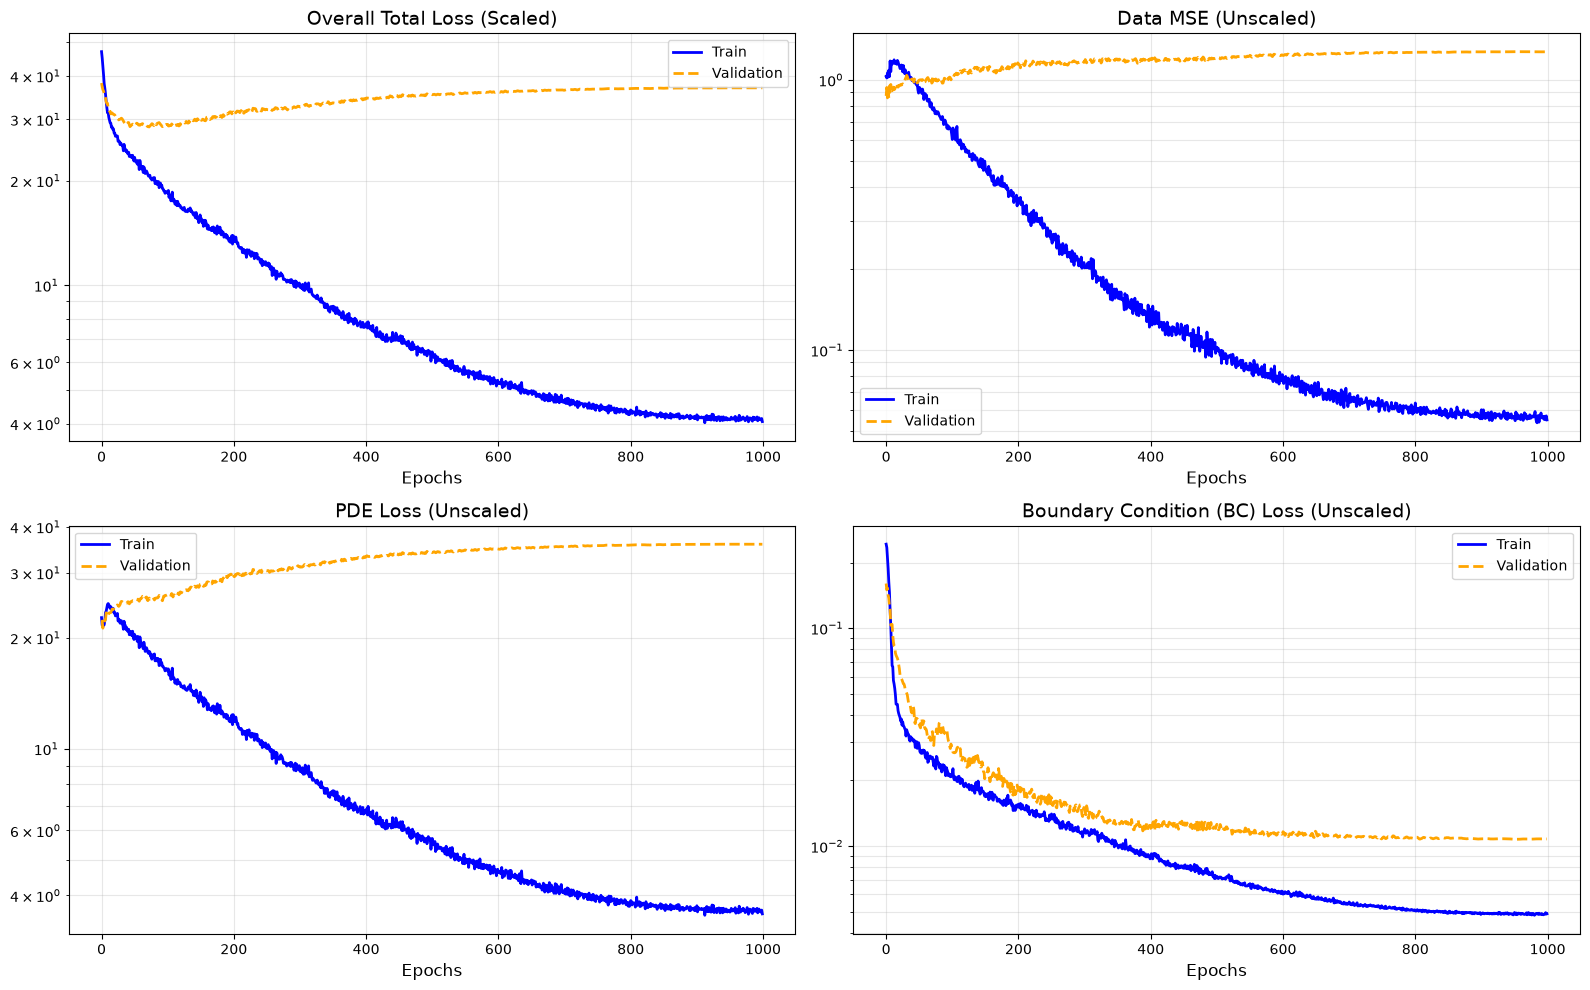

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('total', 'Overall Total Loss (Scaled)'),
    ('data', 'Data MSE (Unscaled)'),
    ('pde', 'PDE Loss (Unscaled)'),
    ('bc', 'Boundary Condition (BC) Loss (Unscaled)')
]

axes_flat = axes.flatten()

for i, (key, title) in enumerate(metrics):
    ax = axes_flat[i]
    ax.plot(history_train[key], color='blue', linewidth=2, label='Train')
    ax.plot(history_val[key], color='orange', linewidth=2, linestyle='--', label='Validation')
    
    ax.set_title(title, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

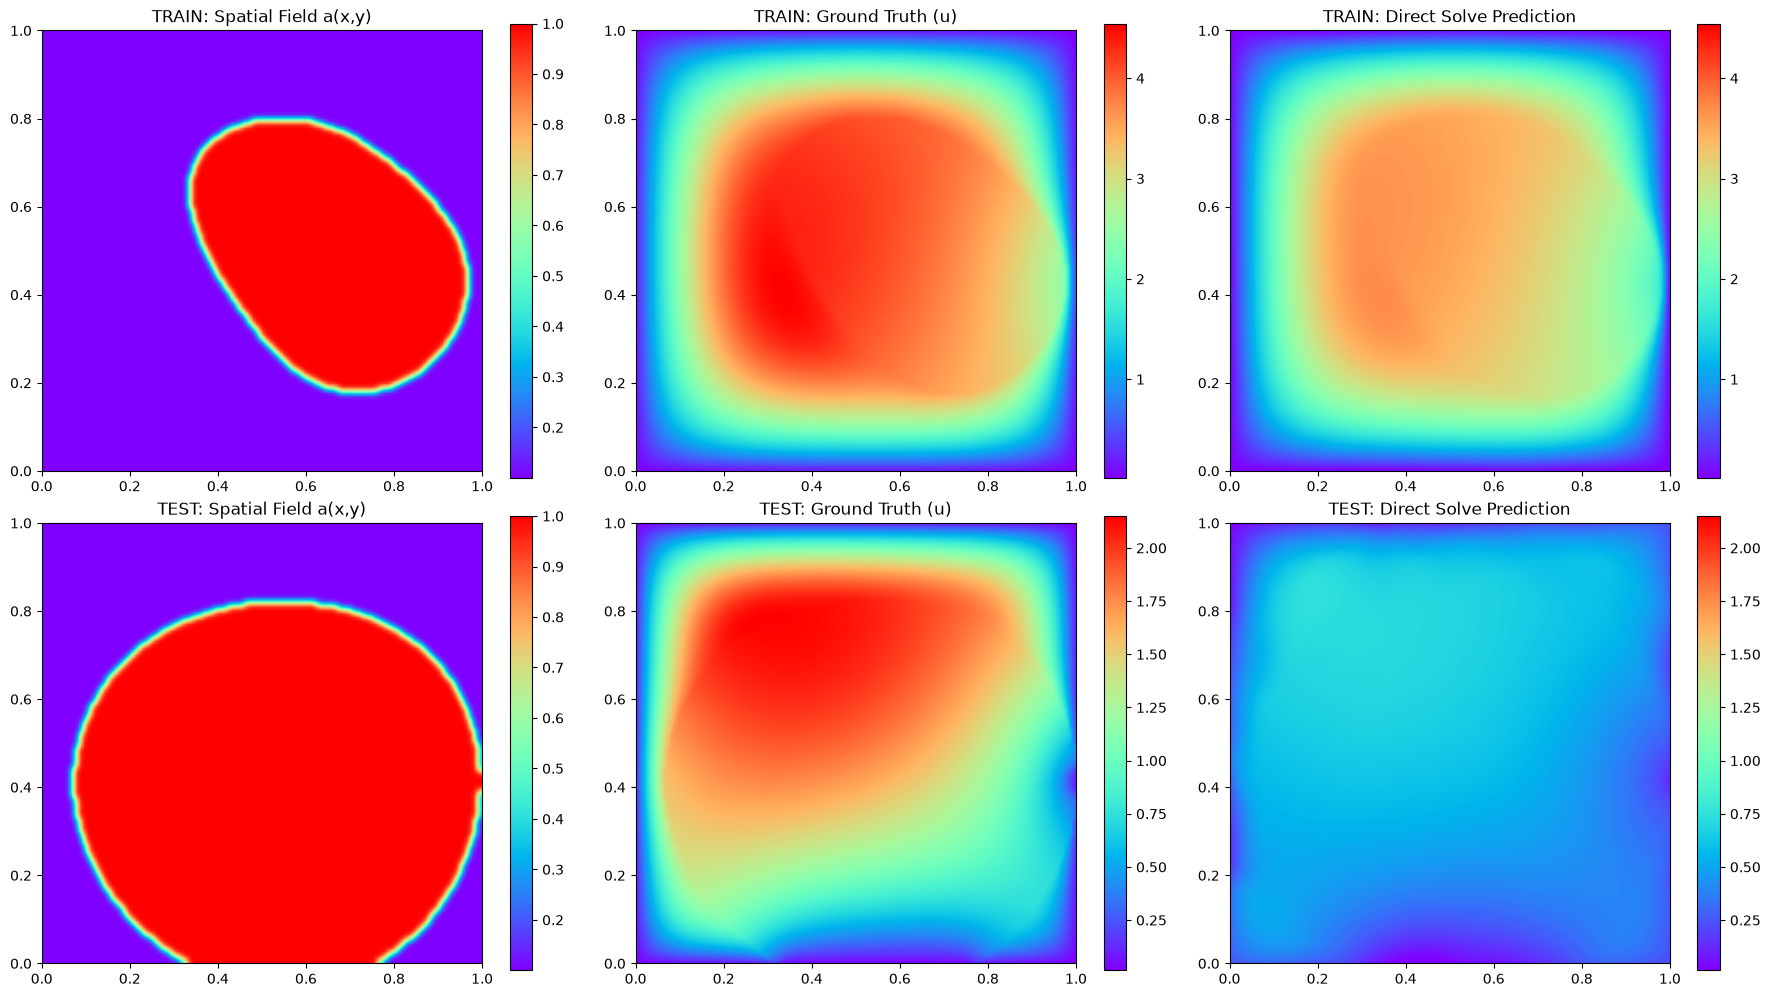

TRAIN Relative L2 Error: 1.5593e-01 (or 15.59%)
TEST  Relative L2 Error: 6.3152e-01 (or 63.15%)


In [ ]:
# Predict & Evaluate on Train and Test Samples
idx_train = 0
idx_test = 0

a_tr, ax_tr, ay_tr, u_sim_tr = train_dataset[idx_train]
a_te, ax_te, ay_te, u_sim_te = test_dataset[idx_test]

# Stack into a batch of size 2
a_batch = jnp.stack([a_tr, a_te], axis=0)
a_x_batch = jnp.stack([ax_tr, ax_te], axis=0)
a_y_batch = jnp.stack([ay_tr, ay_te], axis=0)

# Solve for w
w_batch = update_direct_solve_batch(
    params, x, y, 
    a_batch, a_x_batch, a_y_batch, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

# Evaluate predictions
f_eval = f_spatial_vmap(params, x, y)

w_tr = w_batch[0] 
w_te = w_batch[1] 

u_pred_tr = jnp.dot(f_eval, w_tr)
u_pred_te = jnp.dot(f_eval, w_te)

# Reshape and transpose for Cartesian plotting
a_plot_tr = a_tr.reshape(fine_nx, fine_ny).T
u_sim_plot_tr = u_sim_tr.reshape(fine_nx, fine_ny).T 
u_pred_plot_tr = u_pred_tr.reshape(fine_nx, fine_ny).T

a_plot_te = a_te.reshape(fine_nx, fine_ny).T
u_sim_plot_te = u_sim_te.reshape(fine_nx, fine_ny).T 
u_pred_plot_te = u_pred_te.reshape(fine_nx, fine_ny).T

# Calculate min/max for color scaling so Prediction matches Ground Truth visually
vmin_tr, vmax_tr = float(jnp.min(u_sim_plot_tr)), float(jnp.max(u_sim_plot_tr))
vmin_te, vmax_te = float(jnp.min(u_sim_plot_te)), float(jnp.max(u_sim_plot_te))

ext = [0.0, 1.0, 0.0, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- TRAIN SAMPLE ---
mesh00 = axes[0, 0].imshow(a_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh00, ax=axes[0, 0])
axes[0, 0].set_title(f'TRAIN: Spatial Field a(x,y)')

mesh01 = axes[0, 1].imshow(u_sim_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1, vmin=vmin_tr, vmax=vmax_tr)
fig.colorbar(mesh01, ax=axes[0, 1])
axes[0, 1].set_title('TRAIN: Ground Truth (u)')

mesh02 = axes[0, 2].imshow(u_pred_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1, vmin=vmin_tr, vmax=vmax_tr)
fig.colorbar(mesh02, ax=axes[0, 2])
axes[0, 2].set_title('TRAIN: Direct Solve Prediction')

# --- TEST SAMPLE ---
mesh10 = axes[1, 0].imshow(a_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh10, ax=axes[1, 0])
axes[1, 0].set_title(f'TEST: Spatial Field a(x,y)')

mesh11 = axes[1, 1].imshow(u_sim_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1, vmin=vmin_te, vmax=vmax_te)
fig.colorbar(mesh11, ax=axes[1, 1])
axes[1, 1].set_title('TEST: Ground Truth (u)')

mesh12 = axes[1, 2].imshow(u_pred_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1, vmin=vmin_te, vmax=vmax_te)
fig.colorbar(mesh12, ax=axes[1, 2])
axes[1, 2].set_title('TEST: Direct Solve Prediction')

plt.tight_layout()
plt.show()

# --- Relative L2 Errors ---
err_tr = jnp.linalg.norm(u_pred_tr.flatten() - u_sim_tr.flatten()) / jnp.linalg.norm(u_sim_tr.flatten())
err_te = jnp.linalg.norm(u_pred_te.flatten() - u_sim_te.flatten()) / jnp.linalg.norm(u_sim_te.flatten())

print(f"TRAIN Relative L2 Error: {err_tr:.4e} (or {err_tr * 100:.2f}%)")
print(f"TEST  Relative L2 Error: {err_te:.4e} (or {err_te * 100:.2f}%)")